In [1]:
%%duckdb


SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
)
LIMIT 3

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,455,1 Ave & E 44 St,40.750020,-73.969053,265,Stanton St & Chrystie St,40.722293,-73.991475,18660,Subscriber,1960.0,2,2015-01-01 00:01:00,2015-01-01 00:24:00,23
1,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
2,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6


## Problem 1: Trip duration

### Part 1: Build a Regression Model

Build a regression to predict trip duration by using
- Day of time
- Distance between start and end stations (there might be more than one way to measure it)
- Hour of day
- Weekend indicator
- Don't forget to model bias (this one is intentionally not used in lecture)
- Also any thing you want to end

### Part 2: Experiment Design

- Ensure that you properly design your experiment to report unbiased performance metric you choose

### Part 3 [Optional]: Visualize

- Generate some fictional pickup and dropoff locations for bike trips (random pair selection)
- Estimate trip duration for those say 10 trips
- Visualize them on map using `pydeck` by using redish color for slower trips and greener for faster trips.

**Step 1 — Data çekimi ve feature enginerring**

- Sample ~100k row çünkü limitle almak sadece ilk aylardan alırdı.
- Anomalileri dropla.
- Haversine ve Manhattan distance hesapla.
- Saat, gün ve hafta sonu olup olmadığını çıkar.


In [2]:
%%duckdb -o trips

WITH base AS (
  SELECT 
    *, date_diff('minute', start_at, stop_at) AS duration_min
  FROM (
    SELECT 
      * EXCLUDE (tripduration, starttime, stoptime),
      strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
      strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
    FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
  )
),
feat AS (
  SELECT
    *,
    -- Haversine hesaplama (km)
    2 * 6371 * asin(sqrt(
      pow(sin(radians("end station latitude" - "start station latitude") / 2), 2) +
      cos(radians("start station latitude")) * cos(radians("end station latitude")) *
      pow(sin(radians("end station longitude" - "start station longitude") / 2), 2)
    )) AS haversine_km,
    -- Manhattan hesaplama (km):
    -- 1 derece latitude ~= 111.0 km
    -- 1 derece longitude ~= 111.320 * cos(lat) km
    abs("end station latitude" - "start station latitude") * 111.0
      + abs("end station longitude" - "start station longitude") * 111.320
        * cos(radians(("start station latitude" + "end station latitude") / 2)) AS manhattan_km,
    hour(start_at) AS hour_of_day,
    CAST(strftime(start_at, '%w') AS INTEGER) AS day_of_week,   -- 0 = Sunday ... 6 = Saturday
    CASE WHEN CAST(strftime(start_at, '%w') AS INTEGER) IN (0, 6) THEN 1 ELSE 0 END AS is_weekend
  FROM base
)
SELECT *
FROM feat
WHERE duration_min BETWEEN 1 AND 180
  AND haversine_km > 0
USING SAMPLE 100000 ROWS (reservoir, 42)


,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min,haversine_km,manhattan_km,hour_of_day,day_of_week,is_weekend
0,350,Clinton St & Grand St,40.715595,-73.987030,455,1 Ave & E 44 St,40.750020,-73.969053,18842,Subscriber,1975.0,2,2015-07-16 08:34:58,2015-07-16 08:57:09,23,4.116646,5.337537,8,4,0
1,173,Broadway & W 49 St,40.760683,-73.984527,456,E 53 St & Madison Ave,40.759711,-73.974023,25375,Subscriber,1977.0,1,2016-07-14 07:14:52,2016-07-14 07:19:20,5,0.891293,0.993648,7,4,0
2,2023,E 55 St & Lexington Ave,40.759681,-73.970314,402,Broadway & E 22 St,40.740343,-73.989551,21622,Subscriber,1986.0,1,2016-07-01 15:16:25,2016-07-01 15:30:23,14,2.692512,3.768812,15,5,0
3,515,W 43 St & 10 Ave,40.760094,-73.994618,500,Broadway & W 51 St,40.762288,-73.983362,22299,Subscriber,1981.0,2,2016-10-07 07:50:57,2016-10-07 07:58:42,8,0.978950,1.192655,7,5,0
4,520,W 52 St & 5 Ave,40.759923,-73.976485,518,E 39 St & 2 Ave,40.747804,-73.973442,18735,Subscriber,1989.0,1,2016-12-13 17:09:42,2016-12-13 17:17:04,8,1.371724,1.601826,17,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97667,492,W 33 St & 7 Ave,40.750200,-73.990931,482,W 15 St & 7 Ave,40.739355,-73.999318,18259,Subscriber,1953.0,1,2015-04-28 18:59:00,2015-04-28 19:07:19,8,1.397608,1.911090,18,2,0
97668,304,Broadway & Battery Pl,40.704633,-74.013617,279,Peck Slip & Front St,40.707873,-74.001670,23298,Customer,NaN,0,2015-08-04 12:15:20,2015-08-04 12:45:56,30,1.069542,1.367786,12,2,0
97669,481,S 3 St & Bedford Ave,40.712605,-73.962644,502,Henry St & Grand St,40.714215,-73.981346,17645,Subscriber,1981.0,1,2016-11-06 12:24:20,2016-11-06 12:39:11,15,1.586407,1.756770,12,0,1
97670,529,W 42 St & 8 Ave,40.757570,-73.990985,305,E 58 St & 3 Ave,40.760958,-73.967245,15508,Subscriber,1989.0,1,2016-06-20 05:23:11,2016-06-20 05:32:57,9,2.034723,2.377830,5,1,0


**Step 2 — Biaslı bir linear regression eğitimi**

- Saati cyclical encodelıyorum çünkü saat 23 ve 0 yakın.

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

trips.info()
trips[['duration_min', 'haversine_km', 'manhattan_km', 'hour_of_day', 'is_weekend']].describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97672 entries, 0 to 97671
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   start station id         97672 non-null  int64         
 1   start station name       97672 non-null  object        
 2   start station latitude   97672 non-null  float64       
 3   start station longitude  97672 non-null  float64       
 4   end station id           97672 non-null  int64         
 5   end station name         97672 non-null  object        
 6   end station latitude     97672 non-null  float64       
 7   end station longitude    97672 non-null  float64       
 8   bikeid                   97672 non-null  int64         
 9   usertype                 97537 non-null  object        
 10  birth year               86363 non-null  float64       
 11  gender                   97672 non-null  int64         
 12  start_at                 97672 n

,duration_min,haversine_km,manhattan_km,hour_of_day,is_weekend
count,97672.000000,97672.000000,97672.000000,97672.000000,97672.000000
mean,13.642252,1.901238,2.432493,13.896613,0.228274
std,11.844244,27.759627,39.214519,4.862163,0.419722
min,1.000000,0.036736,0.049615,0.000000,0.000000
25%,6.000000,0.899476,1.138149,10.000000,0.000000
50%,10.000000,1.441482,1.837705,15.000000,0.000000
75%,17.000000,2.318203,2.965934,18.000000,0.000000
max,180.000000,8667.784185,12246.755917,23.000000,1.000000


In [4]:
feature_cols = ['is_weekend', 'haversine_km', 'manhattan_km', 'hour_of_day']
X = trips[feature_cols].copy()
y = trips['duration_min']

# Cyclical encode
X['hour_sin'] = np.sin(2 * np.pi * X['hour_of_day'] / 24)
X['hour_cos'] = np.cos(2 * np.pi * X['hour_of_day'] / 24)
X = X.drop(columns=['hour_of_day'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression(fit_intercept=True)  # fit_intercept=True -> explicit bias term
model.fit(X_train, y_train)

print("Bias (intercept):", model.intercept_)
print(pd.Series(model.coef_, index=X.columns, name='coefficient'))


Bias (intercept): 9.18496777763026
is_weekend       2.205291
haversine_km    17.559200
manhattan_km   -12.423419
hour_sin        -1.081420
hour_cos        -1.622719
Name: coefficient, dtype: float64


1. Hold-out test seti (80/20)
2. Train setinde K-fold cross-validation
3. Burada temporal split daha iyi olabilir ama samplingle çalışmaz bu sebeple tümm veriyi kullanacak kaynak olmadığından böyle yaptım

In [5]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)
print(f"Hold-out test set -> MAE={mae:.3f} min | RMSE={rmse:.3f} min | R^2={r2:.4f}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = -cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
print(f"5-fold CV RMSE -> mean={cv_rmse.mean():.3f} min | std={cv_rmse.std():.3f} min")


Hold-out test set -> MAE=6.718 min | RMSE=10.706 min | R^2=0.1467
5-fold CV RMSE -> mean=73.104 min | std=124.526 min


/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Part 3 [Optional]: Visualize predicted durations for fictional trips


In [6]:
import pydeck as pdk

rng = np.random.default_rng(7)
station_coords = trips[['start station latitude', 'start station longitude']].drop_duplicates().to_numpy()

start_idx = rng.choice(len(station_coords), size=10, replace=True)
end_idx = rng.choice(len(station_coords), size=10, replace=True)

fake_trips = pd.DataFrame({
    'start_lat': station_coords[start_idx, 0],
    'start_lon': station_coords[start_idx, 1],
    'end_lat': station_coords[end_idx, 0],
    'end_lon': station_coords[end_idx, 1],
})

def haversine_km_np(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

fake_trips['haversine_km'] = haversine_km_np(
    fake_trips.start_lat, fake_trips.start_lon, fake_trips.end_lat, fake_trips.end_lon
)
fake_trips['manhattan_km'] = (
    (fake_trips.end_lat - fake_trips.start_lat).abs() * 111.0
    + (fake_trips.end_lon - fake_trips.start_lon).abs() * 111.320
      * np.cos(np.radians((fake_trips.start_lat + fake_trips.end_lat) / 2))
)
fake_trips['is_weekend'] = rng.integers(0, 2, size=10)
hour_of_day = rng.integers(0, 24, size=10)
fake_trips['hour_sin'] = np.sin(2 * np.pi * hour_of_day / 24)
fake_trips['hour_cos'] = np.cos(2 * np.pi * hour_of_day / 24)

X_fake = fake_trips[['is_weekend', 'haversine_km', 'manhattan_km', 'hour_sin', 'hour_cos']]
fake_trips['pred_duration_min'] = model.predict(X_fake)

# Color scale: green = fast, red = slow
dmin, dmax = fake_trips['pred_duration_min'].min(), fake_trips['pred_duration_min'].max()
def to_color(v):
    t = (v - dmin) / (dmax - dmin + 1e-9)
    return [int(255 * t), int(255 * (1 - t)), 0, 180]
fake_trips['color'] = fake_trips['pred_duration_min'].apply(to_color)

arc_layer = pdk.Layer(
    "ArcLayer",
    data=fake_trips,
    get_source_position=['start_lon', 'start_lat'],
    get_target_position=['end_lon', 'end_lat'],
    get_source_color='color',
    get_target_color='color',
    get_width=4,
    pickable=True,
)

view_state = pdk.ViewState(
    latitude=float(fake_trips[['start_lat', 'end_lat']].to_numpy().mean()),
    longitude=float(fake_trips[['start_lon', 'end_lon']].to_numpy().mean()),
    zoom=11.5,
    pitch=30,
)

deck = pdk.Deck(
    layers=[arc_layer],
    initial_view_state=view_state,
    tooltip={"text": "Predicted duration: {pred_duration_min} min"},
)
deck


{
  "initialViewState": {
    "latitude": 40.73031619666549,
    "longitude": -73.97428133343848,
    "pitch": 30,
    "zoom": 11.5
  },
  "layers": [
    {
      "@@type": "ArcLayer",
      "data": [
        {
          "color": [
            21,
            233,
            0,
            180
          ],
          "end_lat": 40.76590936,
          "end_lon": -73.97634151,
          "haversine_km": 3.4451900608873363,
          "hour_cos": -0.9659258262890683,
          "hour_sin": -0.2588190451025208,
          "is_weekend": 1,
          "manhattan_km": 4.870687962908393,
          "pred_duration_min": 13.221759115686567,
          "start_lat": 40.7877214,
          "start_lon": -73.94728331
        },
        {
          "color": [
            35,
            219,
            0,
            180
          ],
          "end_lat": 40.77517793,
          "end_lon": -73.95324922,
          "haversine_km": 1.776709025785594,
          "hour_cos": -0.9659258262890683,
          "hour_sin": -0.2588190451025208,
          "is_weekend": 0,
          "manhattan_km": 2.1486287445829837,
          "pred_duration_min": 15.536559214913327,
          "start_lat": 40.77896784,
          "start_lon": -73.97374737
        },
        {
          "color": [
            160,
            94,
            0,
            180
          ],
          "end_lat": 40.70029511,
          "end_lon": -73.95032283,
          "haversine_km": 6.514255641299484,
          "hour_cos": -1.0,
          "hour_sin": 1.2246467991473532e-16,
          "is_weekend": 0,
          "manhattan_km": 7.209148901789019,
          "pred_duration_min": 35.630525424980476,
          "start_lat": 40.75849116,
          "start_lon": -73.95920622
        },
        {
          "color": [
            254,
            0,
            0,
            180
          ],
          "end_lat": 40.76009437,
          "end_lon": -73.99461843,
          "haversine_km": 8.351311309841881,
          "hour_cos": 0.9659258262890681,
          "hour_sin": -0.25881904510252157,
          "is_weekend": 0,
          "manhattan_km": 8.354802375205184,
          "pred_duration_min": 50.74456787586037,
          "start_lat": 40.6849894,
          "start_lon": -73.99440329
        },
        {
          "color": [
            76,
            178,
            0,
            180
          ],
          "end_lat": 40.70463334,
          "end_lon": -74.01361706,
          "haversine_km": 4.50099418666286,
          "hour_cos": 0.2588190451025203,
          "hour_sin": -0.9659258262890684,
          "is_weekend": 1,
          "manhattan_km": 5.55764158218321,
          "pred_duration_min": 22.00378532176817,
          "start_lat": 40.69363137,
          "start_lon": -73.96223558
        },
        {
          "color": [
            0,
            255,
            0,
            180
          ],
          "end_lat": 40.6902375,
          "end_lon": -73.99203074,
          "haversine_km": 5.620934446068274,
          "hour_cos": 0.2588190451025203,
          "hour_sin": -0.9659258262890684,
          "is_weekend": 0,
          "manhattan_km": 7.946314428302012,
          "pred_duration_min": 9.788265265151917,
          "start_lat": 40.72557,
          "start_lon": -73.94434
        },
        {
          "color": [
            30,
            224,
            0,
            180
          ],
          "end_lat": 40.71285887,
          "end_lon": -73.96590294,
          "haversine_km": 2.1266733363881722,
          "hour_cos": -0.5000000000000004,
          "hour_sin": -0.8660254037844384,
          "is_weekend": 1,
          "manhattan_km": 2.88516099740138,
          "pred_duration_min": 14.637272685822666,
          "start_lat": 40.69608941,
          "start_lon": -73.97803415
        },
        {
          "color": [
            23,
            231,
            0,
            180
          ],
          "end_lat": 40.68962188790333,
          "end_lon": -73.98304268717766,
          "haversine_km": 1.534362262629

### Problem 2: Extending Naive Bayesian

### Part 1: Expand the NB Regression Idea to continous variable

$$
P(gender = a, speed_{bike} = x) = P(gender = a) P(speed_{bike} = x | gender = a)
$$

- Note that $P(speed_{bike} = x | gender = a)$ is  continous distribution.
- Expand the idea
- Build a predictive model for estimation biker gender using the bike speed ?

### Part 2: Use Visualization to decide best distribution 

- How should be $P(speed_{bike} = x | gender = a)$ modeled

In [7]:
%%duckdb -o gender_1_duration


SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
) where gender =1 
LIMIT 3

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
1,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6
2,384,Fulton St & Waverly Ave,40.683178,-73.965964,399,Lafayette Ave & St James Pl,40.688515,-73.964763,19610,Subscriber,1969.0,1,2015-01-01 00:04:00,2015-01-01 00:07:00,3


Klasik Naive Bayes frekans tablosu kullanır olan olaylar için ama continous değerlerde bu işe yaramaz.
Burada da bazı varsayımlar yaparız: Normal distributiona uyması, değişkenlerin bağımsız olması gibi

Hız datasını duck dbyle çeker


In [8]:
%%duckdb -o nb_data

WITH base AS (
  SELECT 
    *, date_diff('minute', start_at, stop_at) AS duration_min
  FROM (
    SELECT 
      * EXCLUDE (tripduration, starttime, stoptime),
      strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
      strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
    FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
  )
),
feat AS (
  SELECT
    *,
    2 * 6371 * asin(sqrt(
      pow(sin(radians("end station latitude" - "start station latitude") / 2), 2) +
      cos(radians("start station latitude")) * cos(radians("end station latitude")) *
      pow(sin(radians("end station longitude" - "start station longitude") / 2), 2)
    )) AS haversine_km
  FROM base
)
SELECT *,
  haversine_km / (duration_min / 60.0) AS speed_kmh
FROM feat
WHERE gender IN (1, 2)                                          -- bilinmeyen cinsiyeti droplar (no woke)
  AND duration_min BETWEEN 1 AND 180
  AND haversine_km > 0
  AND haversine_km / (duration_min / 60.0) BETWEEN 1 AND 40      -- anormal hızları droplar
USING SAMPLE 100000 ROWS (reservoir, 42)


,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min,haversine_km,speed_kmh
0,350,Clinton St & Grand St,40.715595,-73.987030,455,1 Ave & E 44 St,40.750020,-73.969053,18842,Subscriber,1975.0,2,2015-07-16 08:34:58,2015-07-16 08:57:09,23,4.116646,10.739078
1,173,Broadway & W 49 St,40.760683,-73.984527,456,E 53 St & Madison Ave,40.759711,-73.974023,25375,Subscriber,1977.0,1,2016-07-14 07:14:52,2016-07-14 07:19:20,5,0.891293,10.695513
2,2023,E 55 St & Lexington Ave,40.759681,-73.970314,402,Broadway & E 22 St,40.740343,-73.989551,21622,Subscriber,1986.0,1,2016-07-01 15:16:25,2016-07-01 15:30:23,14,2.692512,11.539339
3,515,W 43 St & 10 Ave,40.760094,-73.994618,500,Broadway & W 51 St,40.762288,-73.983362,22299,Subscriber,1981.0,2,2016-10-07 07:50:57,2016-10-07 07:58:42,8,0.978950,7.342122
4,520,W 52 St & 5 Ave,40.759923,-73.976485,518,E 39 St & 2 Ave,40.747804,-73.973442,18735,Subscriber,1989.0,1,2016-12-13 17:09:42,2016-12-13 17:17:04,8,1.371724,10.287929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85726,479,9 Ave & W 45 St,40.760193,-73.991255,380,W 4 St & 7 Ave S,40.734011,-74.002939,21959,Subscriber,1980.0,1,2016-10-22 20:18:54,2016-10-22 20:35:27,17,3.073085,10.846181
85727,492,W 33 St & 7 Ave,40.750200,-73.990931,482,W 15 St & 7 Ave,40.739355,-73.999318,18259,Subscriber,1953.0,1,2015-04-28 18:59:00,2015-04-28 19:07:19,8,1.397608,10.482057
85728,481,S 3 St & Bedford Ave,40.712605,-73.962644,502,Henry St & Grand St,40.714215,-73.981346,17645,Subscriber,1981.0,1,2016-11-06 12:24:20,2016-11-06 12:39:11,15,1.586407,6.345628
85729,529,W 42 St & 8 Ave,40.757570,-73.990985,305,E 58 St & 3 Ave,40.760958,-73.967245,15508,Subscriber,1989.0,1,2016-06-20 05:23:11,2016-06-20 05:32:57,9,2.034723,13.564821


### Part 2: Visualization to pick the right distribution

Hız right skeweddir o da pek Gaussiana uymaz. `log(speed)` sıkıştırır ve daha normal dağılıma benzetir.


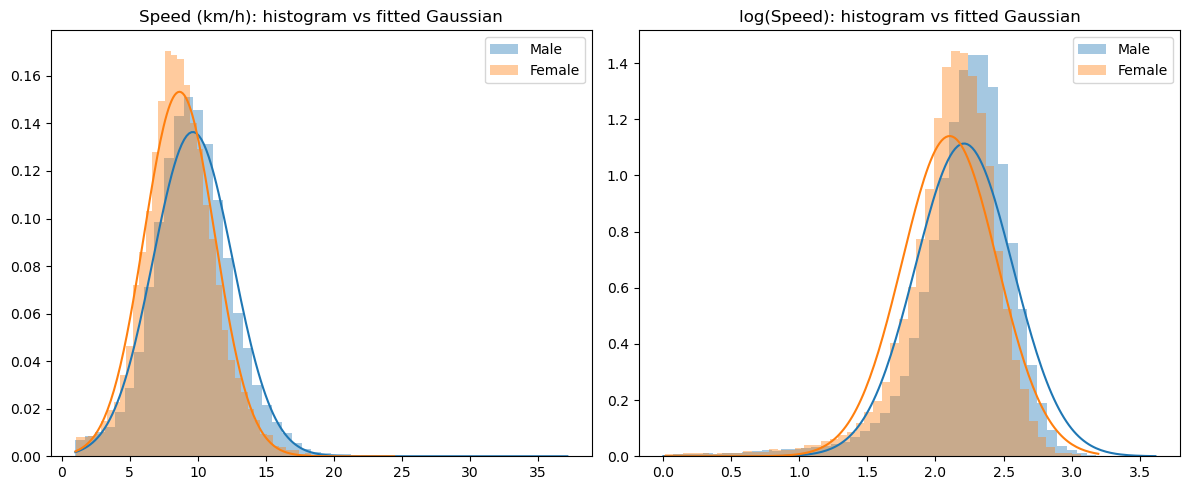

In [9]:
import matplotlib.pyplot as plt
from scipy import stats

nb_data['log_speed'] = np.log(nb_data['speed_kmh'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = {1: 'Male', 2: 'Female'}
colors = {1: 'tab:blue', 2: 'tab:orange'}

for ax, col, title in zip(axes, ['speed_kmh', 'log_speed'], ['Speed (km/h)', 'log(Speed)']):
    for g in (1, 2):
        vals = nb_data.loc[nb_data.gender == g, col]
        ax.hist(vals, bins=50, density=True, alpha=0.4, label=labels[g], color=colors[g])
        mu, sigma = stats.norm.fit(vals)
        xs = np.linspace(vals.min(), vals.max(), 200)
        ax.plot(xs, stats.norm.pdf(xs, mu, sigma), color=colors[g])
    ax.set_title(f"{title}: histogram vs fitted Gaussian")
    ax.legend()

plt.tight_layout()
plt.show()


Sonuçların aynı olduğunu göstemrek için hız ve log hızı fitler sonra Bayesi manual implement eder Gaussian NB de zaten içeride böyle çalışıyor tek feature olduğunda


In [10]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

results = {}
for feat_col in ['speed_kmh', 'log_speed']:
    Xg = nb_data[[feat_col]]
    yg = nb_data['gender']
    Xg_train, Xg_test, yg_train, yg_test = train_test_split(
        Xg, yg, test_size=0.2, stratify=yg, random_state=42
    )

    gnb = GaussianNB()
    gnb.fit(Xg_train, yg_train)
    yg_pred = gnb.predict(Xg_test)

    results[feat_col] = (Xg_train, Xg_test, yg_train, yg_test, gnb, yg_pred)

    print(f"--- Feature: {feat_col} ---")
    print("Accuracy:", accuracy_score(yg_test, yg_pred))
    print("Confusion matrix (rows=true, cols=pred, order=[1,2]):")
    print(confusion_matrix(yg_test, yg_pred, labels=[1, 2]))
    print(classification_report(yg_test, yg_pred))
    print()


--- Feature: speed_kmh ---
Accuracy: 0.7613576718959585
Confusion matrix (rows=true, cols=pred, order=[1,2]):
[[13055     0]
 [ 4092     0]]
              precision    recall  f1-score   support

           1       0.76      1.00      0.86     13055
           2       0.00      0.00      0.00      4092

    accuracy                           0.76     17147
   macro avg       0.38      0.50      0.43     17147
weighted avg       0.58      0.76      0.66     17147


--- Feature: log_speed ---
Accuracy: 0.7597247331894792
Confusion matrix (rows=true, cols=pred, order=[1,2]):
[[13010    45]
 [ 4075    17]]
              precision    recall  f1-score   support

           1       0.76      1.00      0.86     13055
           2       0.27      0.00      0.01      4092

    accuracy                           0.76     17147
   macro avg       0.52      0.50      0.44     17147
weighted avg       0.65      0.76      0.66     17147




/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
def fit_gnb_manual(x, y):
    classes = np.sort(y.unique())
    priors, means, stds = {}, {}, {}
    for c in classes:
        vals = x[y == c]
        priors[c] = len(vals) / len(y)
        means[c] = vals.mean()
        stds[c] = vals.std()
    return classes, priors, means, stds

def predict_proba_manual(x_val, classes, priors, means, stds):
    unnorm = {c: priors[c] * stats.norm.pdf(x_val, means[c], stds[c]) for c in classes}
    total = sum(unnorm.values())
    return {c: p / total for c, p in unnorm.items()}

Xg_train, Xg_test, yg_train, yg_test, gnb, yg_pred = results['log_speed']

classes, priors, means, stds = fit_gnb_manual(Xg_train['log_speed'], yg_train)
print("Priors:", priors)
print("Per-class mean of log_speed:", means)
print("Per-class std of log_speed:", stds)

manual_pred = Xg_test['log_speed'].apply(
    lambda v: max(predict_proba_manual(v, classes, priors, means, stds).items(), key=lambda kv: kv[1])[0]
)
print("Manual Gaussian-Bayes accuracy:", accuracy_score(yg_test, manual_pred))
print("Matches sklearn GaussianNB predictions on", (manual_pred.values == yg_pred).mean() * 100, "% of test rows")


Priors: {np.int64(1): 0.7613291729849527, np.int64(2): 0.23867082701504724}
Per-class mean of log_speed: {np.int64(1): np.float64(2.2108312644885926), np.int64(2): np.float64(2.101504418767873)}
Per-class std of log_speed: {np.int64(1): 0.3581671028553193, np.int64(2): 0.35353107878922263}
Manual Gaussian-Bayes accuracy: 0.759666413949962
Matches sklearn GaussianNB predictions on 99.99416807604828 % of test rows
